# SDC M&A — Deal Counts, PE vs Strategic, Public vs Private

Annual US M&A transaction analysis from SDC Mergers & Acquisitions database.

**Data source:** SDC M&A (`tr_sdc_ma.wrds_ma_details`)

**Reference:** `references/sdc-ma.md`

## Contents
1. Schema discovery
2. Annual M&A deal counts (completed, US targets)
3. PE/LBO vs strategic buyer split
4. Public vs private target breakdown
5. Summary: M&A practice area sizing

In [1]:
import psycopg2
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
})

conn = psycopg2.connect(
    host='wrds-pgdata.wharton.upenn.edu',
    port=9737,
    database='wrds',
    user='eddyhu',
    sslmode='require'
)
print('Connected to WRDS')

Connected to WRDS


## 1. Schema Discovery

In [2]:
cur = conn.cursor()

# Confirm SDC M&A schema
cur.execute("""
    SELECT schema_name
    FROM information_schema.schemata
    WHERE schema_name ILIKE '%tr_sdc%'
    ORDER BY schema_name
""")
print('SDC schemas:', cur.fetchall())

SDC_MA_SCHEMA = 'tr_sdc_ma'
MA_TABLE = 'tr_sdc_ma.wrds_ma_details'
print(f'Using M&A table: {MA_TABLE}')

SDC schemas: [('tr_sdc_ma',), ('tr_sdc_ma_old',), ('tr_sdc_ni',), ('tr_sdc_ni_old',), ('tr_sdc_samples',), ('tr_sdc_samples_new',)]
Using M&A table: tr_sdc_ma.wrds_ma_details


In [3]:
# List tables in tr_sdc_ma
cur.execute("""
    SELECT table_name,
           pg_size_pretty(pg_total_relation_size(
               quote_ident(table_schema)||'.'||quote_ident(table_name))) AS size
    FROM information_schema.tables
    WHERE table_schema = %s
    ORDER BY table_name
""", (SDC_MA_SCHEMA,))
print('Tables:', cur.fetchall())

Tables: [('wrds_ma_advisors', '123 MB'), ('wrds_ma_competition', '1344 kB'), ('wrds_ma_details', '1797 MB'), ('wrds_ma_events', '442 MB'), ('wrds_ma_purpose', '49 MB'), ('wrds_ma_related', '42 MB')]


In [4]:
# Row count and date range
cur.execute("""
    SELECT
        COUNT(*)                        AS total_rows,
        COUNT(DISTINCT master_deal_no)  AS unique_deals,
        MIN(dateann)                    AS earliest,
        MAX(dateann)                    AS latest
    FROM tr_sdc_ma.wrds_ma_details
    WHERE tnation = 'United States'
""")
row = cur.fetchone()
print(f'US target deals: {row[1]:,.0f}')
print(f'Date range:      {row[2]} → {row[3]}')

US target deals: 452,174
Date range:      1965-01-01 → 2026-03-31


## 2. Annual M&A Deal Counts

In [5]:
# Pull completed/withdrawn US M&A deals
query_ma = """
SELECT
    master_deal_no,
    dateann             AS date_announced,
    dateeff             AS date_effective,
    status,
    statuscode,
    amanames            AS acquiror_name,
    tmanames            AS target_name,
    anation             AS acquiror_nation,
    tnation             AS target_nation,
    apublic,
    tpublic,
    deal_value,
    form                AS form_of_transaction,
    consid              AS consideration_paid,
    pctacq              AS pct_acquired,
    albofirm            AS lbo_flag,
    sftype              AS source_of_financing,
    attitude,
    pm4wk               AS premium_4wk,
    pct_cash,
    pct_stk,
    master_cusip        AS target_cusip,
    tsicp               AS target_sic
FROM tr_sdc_ma.wrds_ma_details
WHERE tnation = 'United States'
  AND statuscode IN ('C', 'W')
  AND dateann BETWEEN '1985-01-01' AND '2026-12-31'
"""
df = pd.read_sql(query_ma, conn)
df['announce_year'] = pd.to_datetime(df['date_announced']).dt.year
df['deal_value'] = pd.to_numeric(df['deal_value'], errors='coerce')
df['pct_acquired'] = pd.to_numeric(df['pct_acquired'], errors='coerce')

print(f'Total US deals (completed+withdrawn): {len(df):,}')
print('Status breakdown:')
print(df['statuscode'].value_counts())
df.head(3)

/Users/vwh7mb/.tmp/ipykernel_28359/744597227.py:32: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query_ma, conn)


Total US deals (completed+withdrawn): 372,715
Status breakdown:
statuscode
C    359751
W     12964
Name: count, dtype: int64


,master_deal_no,date_announced,date_effective,status,statuscode,acquiror_name,target_name,acquiror_nation,target_nation,apublic,...,pct_acquired,lbo_flag,source_of_financing,attitude,premium_4wk,pct_cash,pct_stk,target_cusip,target_sic,announce_year
0,1000018020,2000-04-24,2000-07-06,Completed,C,E Stanley Kroenke,Colorado Avalanche,United States,United States,Inv.,...,100.0,No,None,Friendly,NaN,NaN,NaN,19629F,7941,2000
1,1000022020,2000-04-24,2000-05-30,Completed,C,Chargeurs SA,Ivex Packaging-Coating Bus,France,United States,Public,...,100.0,No,None,Friendly,NaN,100.0,NaN,46667H,2295,2000
2,1000023020,2000-04-24,2000-04-24,Completed,C,Aspen Group Resources Corp,Redterra Resources-Oil Ppty,United States,United States,Public,...,100.0,No,None,Friendly,NaN,100.0,NaN,75791H,1311,2000


In [6]:
# Clean sample: completed, majority acquisitions
FULL_CONTROL_FORMS = {
    'Merger', 'Acq. of Majority Interest',
    'Acq. of Remaining Interest', 'Asset Acquisition'
}

df_comp = df[
    (df['statuscode'] == 'C') &
    (df['form_of_transaction'].isin(FULL_CONTROL_FORMS) | df['form_of_transaction'].isna()) &
    (df['pct_acquired'].isna() | (df['pct_acquired'] >= 50))
].copy()

print(f'Clean completed deals: {len(df_comp):,}')

# Annual counts and volume
annual = df_comp.groupby('announce_year').agg(
    n_deals=('master_deal_no', 'count'),
    n_with_value=('deal_value', lambda x: x.notna().sum()),
    total_value_bn=('deal_value', lambda x: x.sum() / 1e3),
    avg_value_mm=('deal_value', 'mean')
)
annual = annual[(annual.index >= 1985) & (annual.index <= 2026)]
print(annual.tail(10))

Clean completed deals: 50,124
               n_deals  n_with_value  total_value_bn  avg_value_mm
announce_year                                                     
2017              1421           598      671.944542   1123.653080
2018              1361           653      808.588362   1238.267017
2019              1124           582      969.115768   1665.147368
2020              1125           529      666.374076   1259.686344
2021              1466           911     1284.303355   1409.773167
2022              1044           534      745.622614   1396.297030
2023              1080           493      701.173787   1422.259203
2024               985           483      715.131963   1480.604478
2025               945           450      675.244890   1500.544200
2026               114            28        7.544231    269.436821


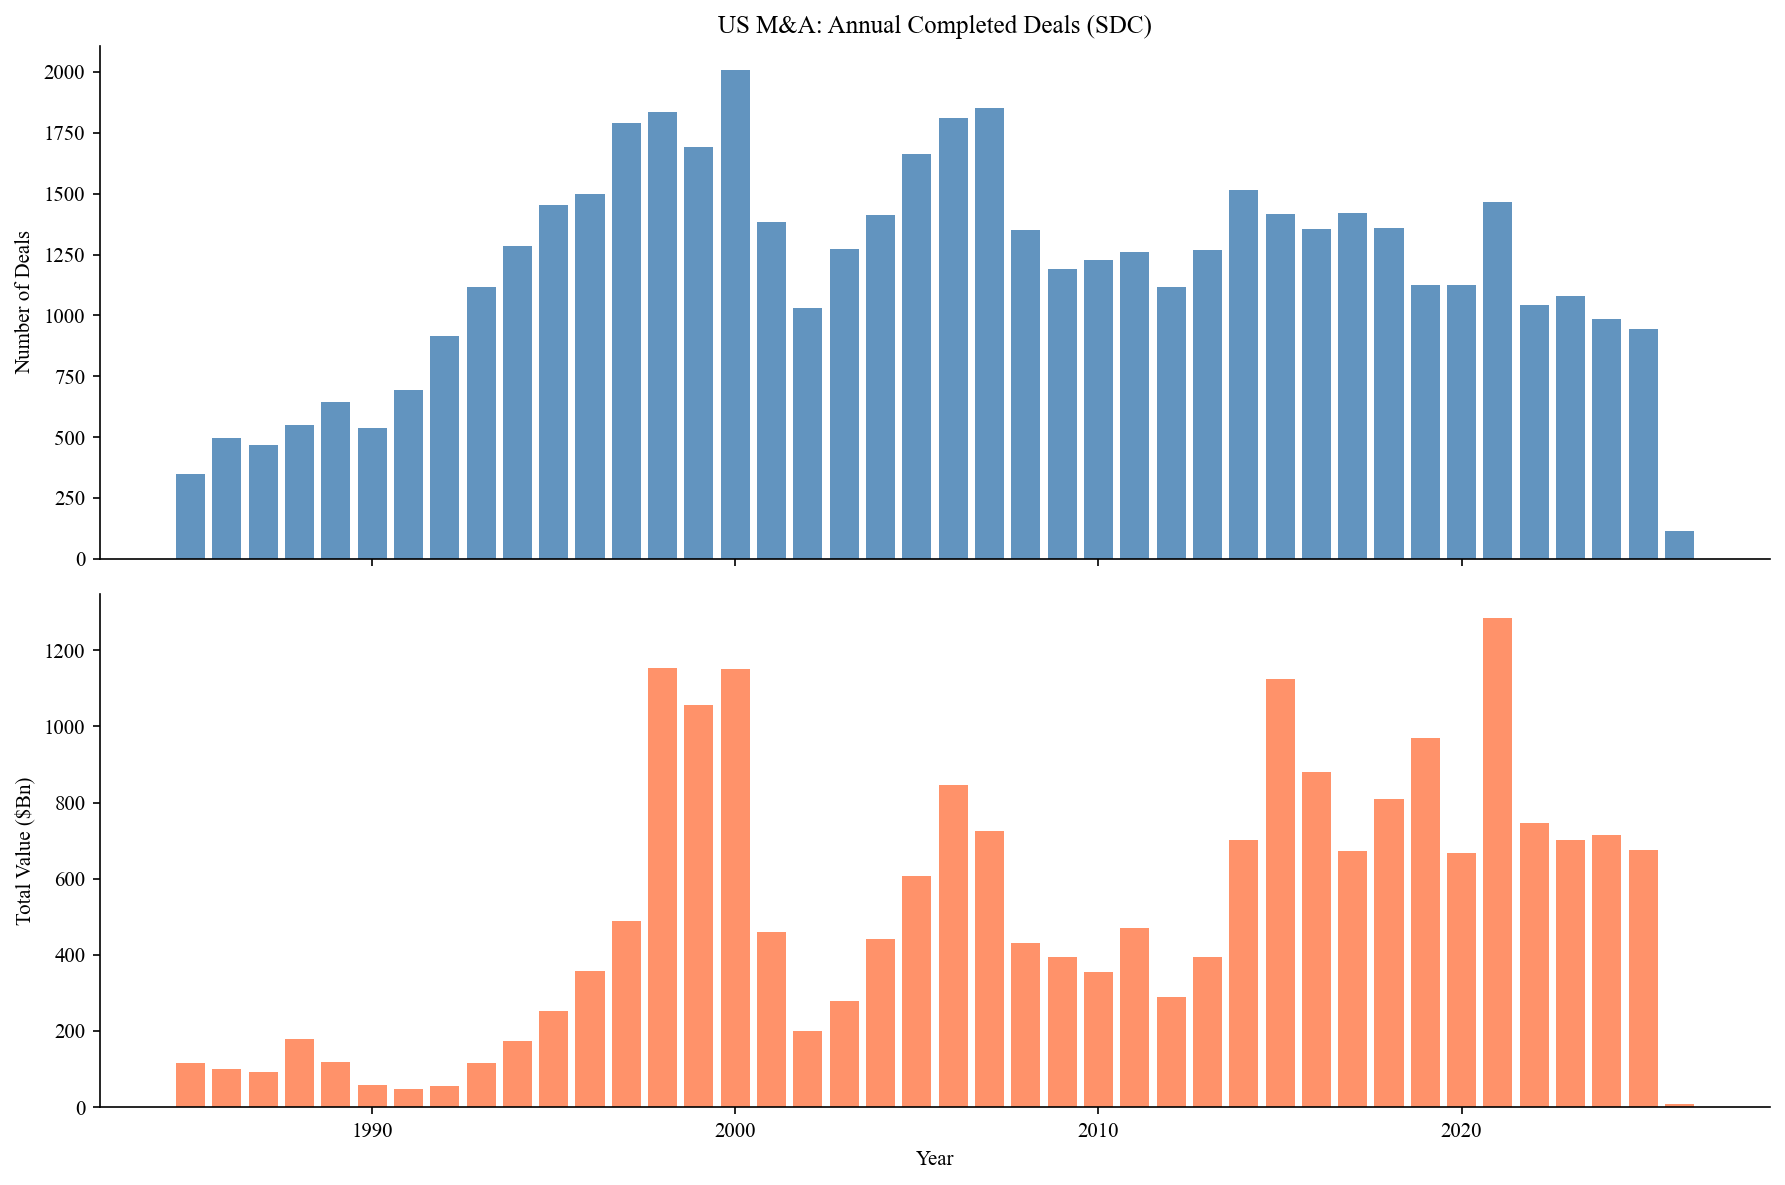

In [7]:
# Plot: annual deal count
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].bar(annual.index, annual['n_deals'], color='steelblue', alpha=0.85)
axes[0].set_ylabel('Number of Deals')
axes[0].set_title('US M&A: Annual Completed Deals (SDC)')

axes[1].bar(annual.index, annual['total_value_bn'], color='coral', alpha=0.85)
axes[1].set_ylabel('Total Value ($Bn)')
axes[1].set_xlabel('Year')

plt.tight_layout()
plt.savefig('/tmp/ma_annual.png', dpi=150, bbox_inches='tight')
plt.savefig('/tmp/ma_annual.svg', dpi=150, bbox_inches='tight')
plt.show()

## 3. PE/LBO vs Strategic Buyer

In [8]:
# Check LBO flag and source of financing
print('LBO flag (albofirm) distribution:')
print(df_comp['lbo_flag'].value_counts(dropna=False).head(5))
print()
print('Source of financing top values:')
print(df_comp['source_of_financing'].value_counts(dropna=False).head(15))

LBO flag (albofirm) distribution:
lbo_flag
No     49537
Yes      587
Name: count, dtype: int64

Source of financing top values:
source_of_financing
None                                           43302
Corporate Funds                                 1080
Borrowings                                       762
Line of Credit                                   686
Corporate Funds, Borrowings                      642
Common Stock Issue                               528
Corporate Funds, Line of Credit                  385
Debt Issue                                       257
Borrowings, Line of Credit                       248
Corporate Funds, Borrowings, Line of Credit      158
Debt Issue, Corporate Funds                      148
Common Stock Issue, Corporate Funds              145
Bridge Loan                                      144
Debt Issue, Common Stock Issue                   124
Common Stock Issue, Borrowings                   112
Name: count, dtype: int64


In [9]:
# PE identification: LBO flag OR name pattern match
PE_NAME_PATTERNS = (
    r'private equity|buyout|capital partners|equity partners|'
    r'apollo|blackstone|carlyle|kkr|tpg|warburg pincus|bain capital|'
    r'advent|vista equity|thoma bravo|francisco partners|silver lake|'
    r'cerberus|ares management|oaktree|bc partners|apax|'
    r'general atlantic|insight partners|summit partners'
)

df_comp['pe_lbo_flag'] = df_comp['lbo_flag'] == 'Yes'
df_comp['pe_name_flag'] = df_comp['acquiror_name'].str.lower().str.contains(
    PE_NAME_PATTERNS, na=False, regex=True)

df_comp['is_pe'] = df_comp['pe_lbo_flag'] | df_comp['pe_name_flag']

print(f'PE deals:        {df_comp["is_pe"].sum():,} ({df_comp["is_pe"].mean():.1%})')
print(f'Strategic deals: {(~df_comp["is_pe"]).sum():,} ({(~df_comp["is_pe"]).mean():.1%})')

PE deals:        784 (1.6%)
Strategic deals: 49,340 (98.4%)


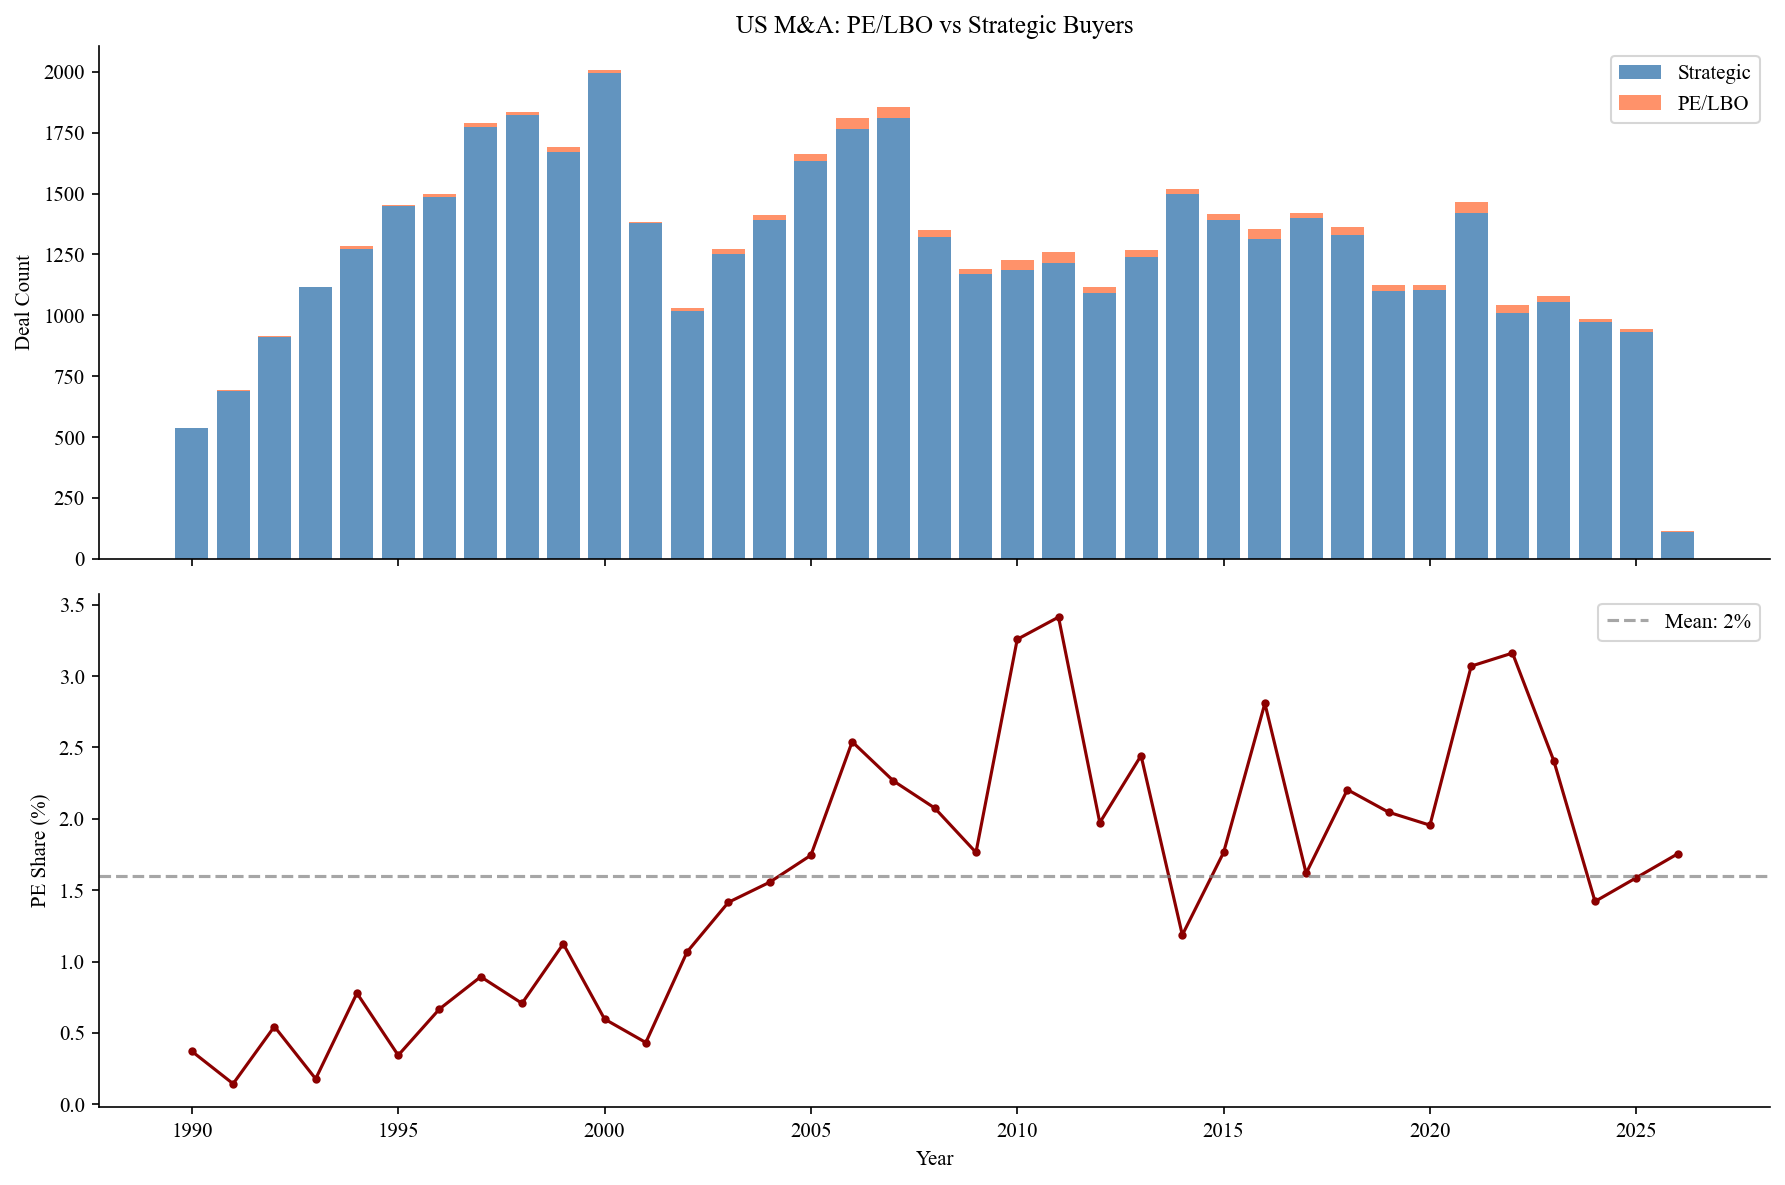

In [10]:
# Annual PE vs strategic split
pe_annual = (df_comp.groupby(['announce_year', 'is_pe'])
             .agg(n_deals=('master_deal_no', 'count'),
                  total_value_bn=('deal_value', lambda x: x.sum() / 1e3))
             .reset_index())

pe_pivot = pe_annual.pivot_table(
    index='announce_year', columns='is_pe',
    values=['n_deals', 'total_value_bn'], aggfunc='sum'
).fillna(0)
# Flatten multi-level columns: (metric, is_pe) -> readable names
pe_pivot.columns = [f"{'pe' if pe else 'strategic'}_{m}" 
                    for m, pe in pe_pivot.columns]
if 'strategic_n_deals' not in pe_pivot.columns:
    pe_pivot['strategic_n_deals'] = 0
if 'pe_n_deals' not in pe_pivot.columns:
    pe_pivot['pe_n_deals'] = 0
pe_pivot['strategic_deals'] = pe_pivot.get('strategic_n_deals', 0)
pe_pivot['pe_deals'] = pe_pivot.get('pe_n_deals', 0)
pe_pivot['strategic_value'] = pe_pivot.get('strategic_total_value_bn', 0)
pe_pivot['pe_value'] = pe_pivot.get('pe_total_value_bn', 0)
pe_pivot['pe_share_pct'] = (
    pe_pivot['pe_deals'] /
    (pe_pivot['pe_deals'] + pe_pivot['strategic_deals']).replace(0, float('nan')) * 100
).fillna(0)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
pp = pe_pivot[(pe_pivot.index >= 1990) & (pe_pivot.index <= 2026)]

axes[0].bar(pp.index, pp['strategic_deals'], label='Strategic',
            color='steelblue', alpha=0.85)
axes[0].bar(pp.index, pp['pe_deals'], bottom=pp['strategic_deals'],
            label='PE/LBO', color='coral', alpha=0.85)
axes[0].set_ylabel('Deal Count')
axes[0].set_title('US M&A: PE/LBO vs Strategic Buyers')
axes[0].legend()

axes[1].plot(pp.index, pp['pe_share_pct'], color='darkred', linewidth=1.5,
             marker='o', markersize=3)
axes[1].axhline(pp['pe_share_pct'].mean(), color='gray', linestyle='--',
                alpha=0.7, label=f'Mean: {pp["pe_share_pct"].mean():.0f}%')
axes[1].set_ylabel('PE Share (%)')
axes[1].set_xlabel('Year')
axes[1].legend()

plt.tight_layout()
plt.savefig('/tmp/ma_pe_strategic.png', dpi=150, bbox_inches='tight')
plt.savefig('/tmp/ma_pe_strategic.svg', dpi=150, bbox_inches='tight')
plt.show()

## 4. Public vs Private Target

In [11]:
# Public/private distribution
print('Target public flag (tpublic) distribution:')
print(df_comp['tpublic'].value_counts(dropna=False).head(10))

Target public flag (tpublic) distribution:
tpublic
Priv.     29612
Public    12780
Sub.       7287
J.V.        336
Mutual       59
Govt.        50
Name: count, dtype: int64


Target type groups: ['Other', 'Private', 'Public', 'Subsidiary']


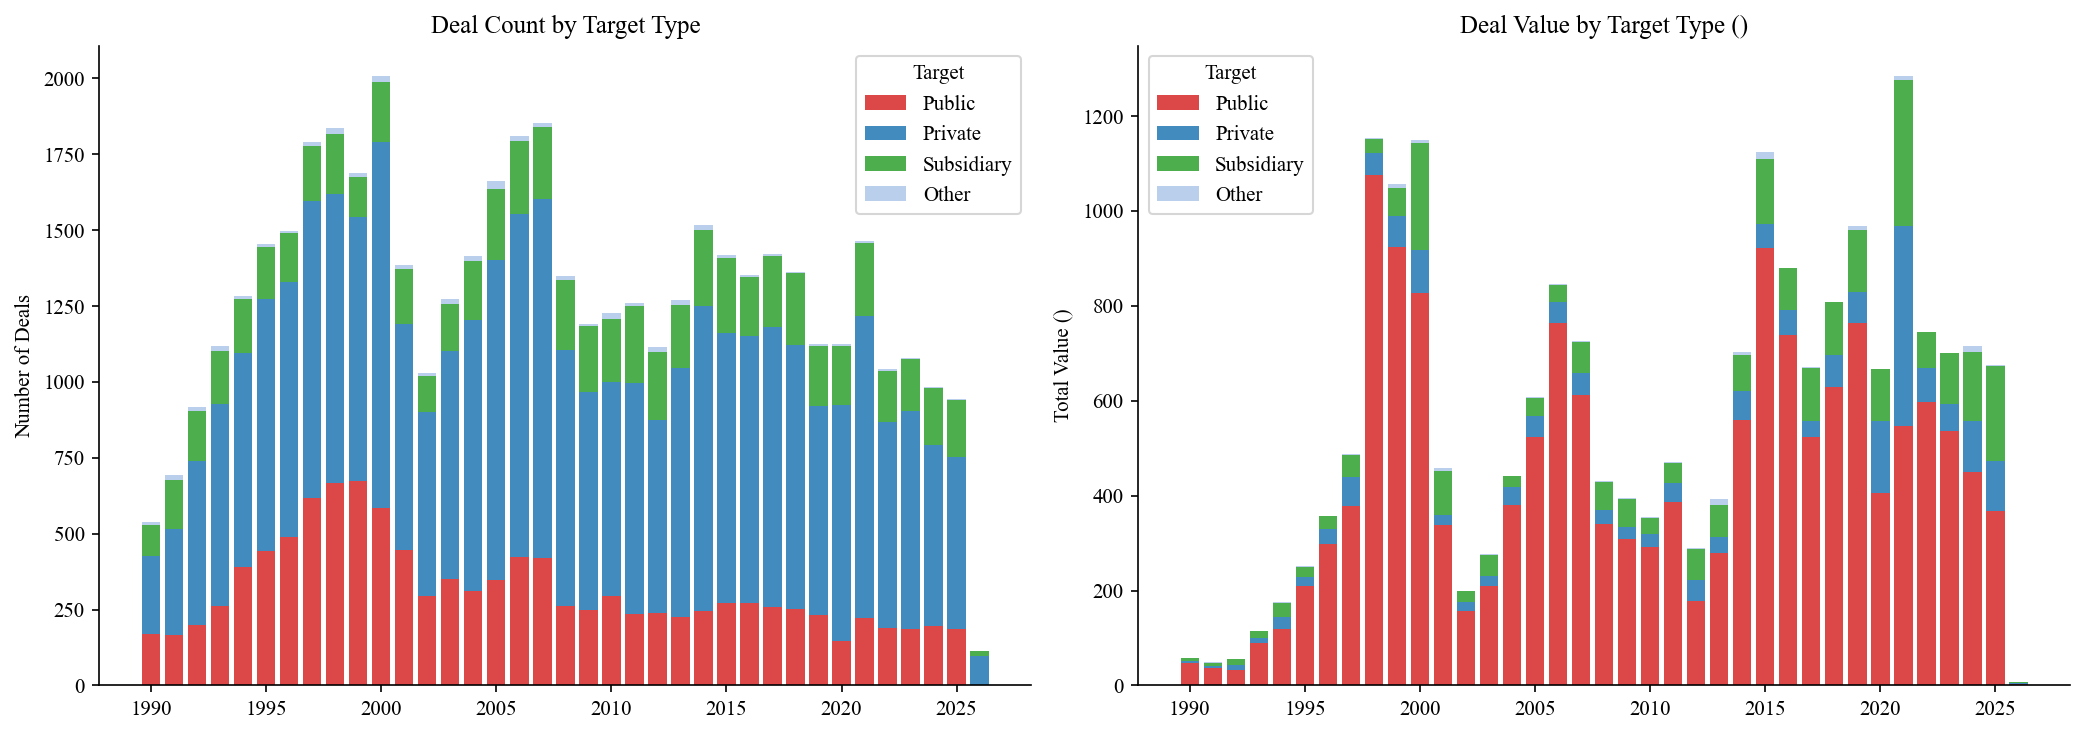


NOTE: Public targets = ~5-8% of deal count but ~40-60% of dollar volume.
Public-target deals require proxy/tender offer filings — intensive legal work.


In [12]:
# Map tpublic to clean groups
tpublic_map = {
    'Public':  'Public',
    'Priv.':   'Private',
    'Sub.':    'Subsidiary',
}
df_comp['tpublic_group'] = df_comp['tpublic'].map(tpublic_map).fillna('Other')

# Annual: public target vs private target
pub_private = df_comp.groupby(['announce_year', 'tpublic_group']).agg(
    n_deals=("master_deal_no", "count"),
    total_value_bn=("deal_value", lambda x: x.sum() / 1e3)
).reset_index()

pub_pvt_pivot = pub_private.pivot_table(
    index="announce_year", columns="tpublic_group",
    values=["n_deals", "total_value_bn"], aggfunc="sum"
).fillna(0)

print("Target type groups:", pub_pvt_pivot.columns.get_level_values(1).unique().tolist())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pp = pub_pvt_pivot[(pub_pvt_pivot.index >= 1990) & (pub_pvt_pivot.index <= 2026)]
n = pp["n_deals"]
v = pp["total_value_bn"]

colors = {"Public": "#d62728", "Private": "#1f77b4", "Subsidiary": "#2ca02c", "Other": "#aec7e8"}
plot_order = [t for t in ["Public", "Private", "Subsidiary", "Other"] if t in n.columns]

for ax, data, ylabel, title in [
    (axes[0], n, "Number of Deals", "Deal Count by Target Type"),
    (axes[1], v, "Total Value ()", "Deal Value by Target Type ()")
]:
    bottom = np.zeros(len(data))
    for ttype in plot_order:
        ax.bar(data.index, data[ttype], bottom=bottom,
               label=ttype, color=colors[ttype], alpha=0.85)
        bottom += data[ttype].values
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.legend(title="Target")

plt.tight_layout()
plt.savefig("/tmp/ma_public_private.png", dpi=150, bbox_inches="tight")
plt.savefig("/tmp/ma_public_private.svg", dpi=150, bbox_inches="tight")
plt.show()
print()
print("NOTE: Public targets = ~5-8% of deal count but ~40-60% of dollar volume.")
print("Public-target deals require proxy/tender offer filings — intensive legal work.")

## 5. Summary Statistics

In [13]:
# Recent 5-year averages
recent = df_comp[df_comp["announce_year"].between(2019, 2023)]

print("=== M&A Practice Area Summary (2019-2023 average) ===")
print(f"Total completed US deals/year:    {len(recent)/5:,.0f}")
print(f"  PE/LBO deals/year:              {recent["is_pe"].sum()/5:,.0f} ({recent["is_pe"].mean():.1%} of total)")
print(f"  Strategic deals/year:           {(~recent["is_pe"]).sum()/5:,.0f}")
print(f"  Public target deals/year:       {(recent["tpublic"]=="Public").sum()/5:,.0f}")
print(f"  Deals w/ disclosed value:       {recent["deal_value"].notna().sum()/5:,.0f}")
print(f"  Avg disclosed deal value:       ${recent["deal_value"].mean():,.0f}M")
print()
print("Deal size distribution (disclosed values):")
bins = [0, 25, 100, 500, 1000, 5000, float("inf")]
labels = ["<$25M", "$25-100M", "$100-500M", "$500M-1Bn", "$1-5Bn", ">$5Bn"]
recent_val = recent.dropna(subset=["deal_value"])
recent_val = recent_val[recent_val["deal_value"] > 0]
size_dist = pd.cut(recent_val["deal_value"], bins=bins, labels=labels).value_counts().sort_index()
for label, count in size_dist.items():
    print(f"  {label:15s}: {count/5:6.0f} deals/year")

=== M&A Practice Area Summary (2019-2023 average) ===
Total completed US deals/year:    1,168
  PE/LBO deals/year:              30 (2.6% of total)
  Strategic deals/year:           1,138
  Public target deals/year:       195
  Deals w/ disclosed value:       610
  Avg disclosed deal value:       $1,432M

Deal size distribution (disclosed values):
  <$25M          :    129 deals/year
  $25-100M       :    111 deals/year
  $100-500M      :    153 deals/year
  $500M-1Bn      :     65 deals/year
  $1-5Bn         :    113 deals/year
  >$5Bn          :     38 deals/year
